In [129]:
import torch
from torchvision.transforms import v2
from torchvision.io import decode_image
import matplotlib.pyplot as plt

from helpers import plot

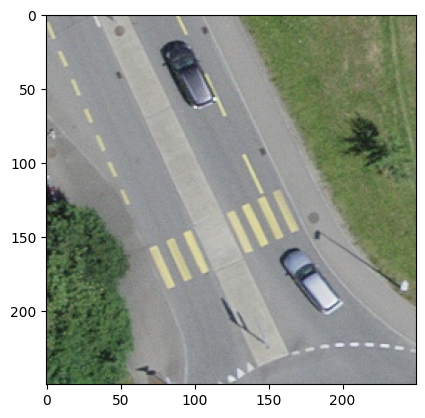

In [130]:
img_path = "data/raw_data/y/2613050_1179750.png"
img = decode_image(img_path)
img = img.numpy().transpose(1, 2, 0)
plt.imshow(img)

## Basic Augmentation

### Geometry

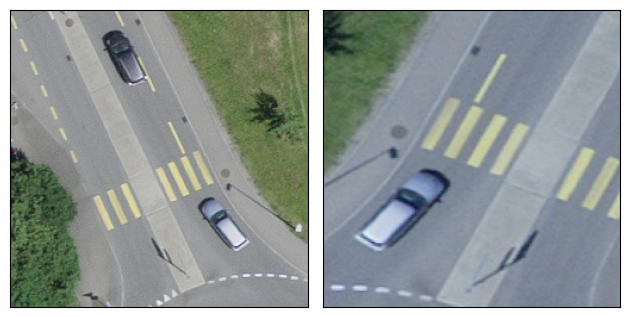

In [131]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

out = transforms(img)
plot([img, out])

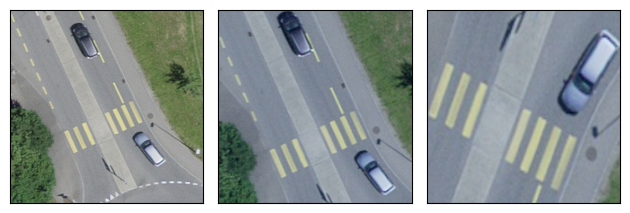

In [132]:
plots = [img]
for i in range(2):
    out = transforms(img)
    plots.append(out)

plot(plots)

Random Crop kann die wichtige Information (Zebrastreifen vorhanden) löschen --> nicht verwenden

### Color

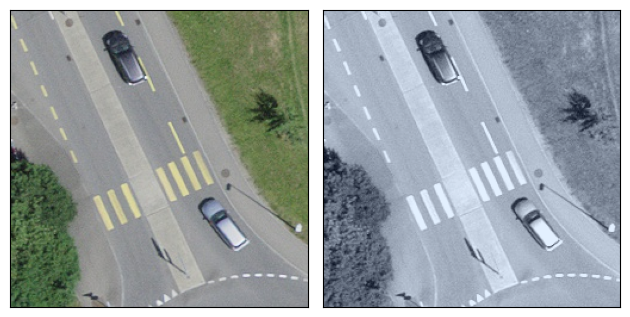

In [133]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.GaussianBlur(kernel_size=(3, 7)),
    v2.RandomGrayscale(p=0.3),
    v2.ColorJitter(brightness=0.5, contrast=0.7, saturation=0.8),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

out = transforms(img)
plot([img, out])

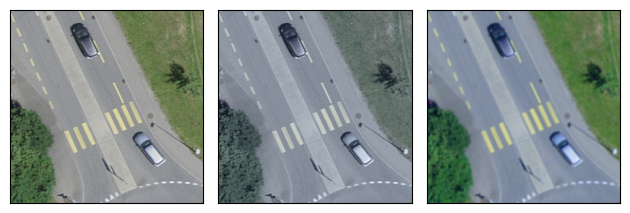

In [134]:
plots = [img]
for i in range(2):
    out = transforms(img)
    plots.append(out)

plot(plots)

--> Farbe nicht egal, raus

### Perspective

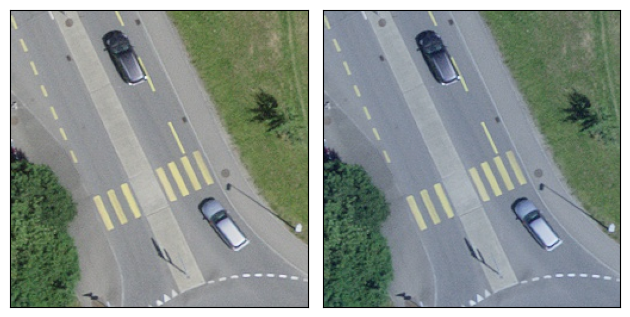

In [135]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.RandomPerspective(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

out = transforms(img)
plot([img, out])

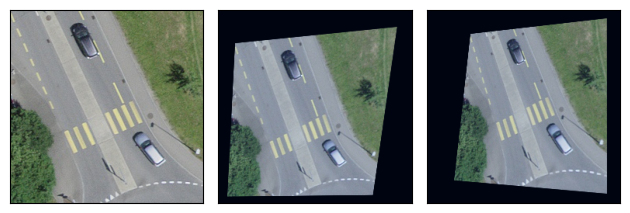

In [136]:
plots = [img]
for i in range(2):
    out = transforms(img)
    plots.append(out)

plot(plots)

### Padding

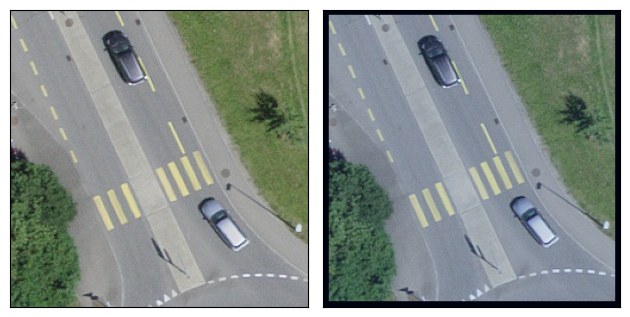

In [137]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.Pad(padding=5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

out = transforms(img)
plot([img, out])

### Kombination

In [ ]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.3),
    v2.RandomVerticalFlip(p=0.2),
    v2.GaussianBlur(kernel_size=(3, 7)),
    v2.ColorJitter(brightness=0.5, contrast=0.7, saturation=0.8),
    v2.RandomPerspective(p=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

out = transforms(img)

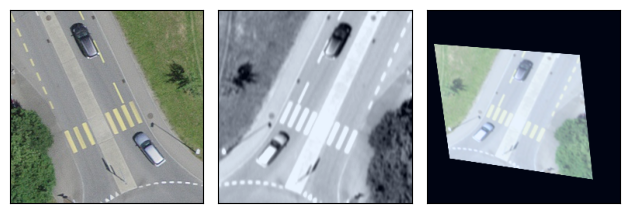

In [139]:
plots = [img]
for i in range(2):
    out = transforms(img)
    plots.append(out)

plot(plots)